# Part 4: Best Model Training and Sample Generation

This notebook trains the best model for multiple epochs, generates unconditional and prefix conditioned SVG samples at multiple temperatures, evaluates them quantitatively and qualitatively, and produces rendered grids.

It loads the tokenizer and data from Part 1, and Part 2/3 summaries to decide the best model and LR strategy.


In [1]:
!pip install tokenizers matplotlib numpy tqdm scipy cairosvg lxml mup Pillow -q

In [2]:
import os
import re
import json
import math
import time
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from lxml import etree
import cairosvg
from io import BytesIO
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer
from mup import MuReadout, set_base_shapes, MuAdamW

PROJECT_DIR = Path("ml_final_project")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
PLOT_DIR = PROJECT_DIR / "plots"
GEN_DIR = OUTPUT_DIR / "generated"

for d in [OUTPUT_DIR, PLOT_DIR, GEN_DIR, GEN_DIR / "unconditional", GEN_DIR / "prefix"]:
    d.mkdir(exist_ok=True, parents=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    # print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: NVIDIA A100-SXM4-40GB


## Step 1: Load Data, Tokenizer, and Previous Results

In [3]:
tokenizer_path = DATA_DIR / "svg_tokenizer.json"
tokenizer = Tokenizer.from_file(str(tokenizer_path))
VOCAB_SIZE = tokenizer.get_vocab_size()
print(f"Loaded tokenizer, vocab size: {VOCAB_SIZE}")

for split in ["train", "val", "test"]:
    data = np.memmap(str(DATA_DIR / f"{split}.bin"), dtype=np.uint16, mode='r')
    print(f"  {split}.bin: {len(data):,} tokens")

with open(OUTPUT_DIR / "part2_summary.json", "r") as f:
    part2_summary = json.load(f)

with open(OUTPUT_DIR / "part3_summary.json", "r") as f:
    part3_summary = json.load(f)

sp_xl_loss = part2_summary["models"]["XL"]["final_val_loss"]
mup_xl_loss = part3_summary["comparison"]["XL"]["mup_val_loss"]

if mup_xl_loss < sp_xl_loss:
    USE_MUP = True
    BEST_LR = part3_summary["best_mup_lr"]
    print(f"\nmuP is better on XL (muP={mup_xl_loss:.4f} vs SP={sp_xl_loss:.4f})")
else:
    USE_MUP = False
    BEST_LR = part2_summary["best_lr"]
    print(f"\nSP is better on XL (SP={sp_xl_loss:.4f} vs muP={mup_xl_loss:.4f})")

print(f"Using {'muP' if USE_MUP else 'SP'} with LR {BEST_LR:.1e}")

Loaded tokenizer, vocab size: 4096
  train.bin: 116,379,858 tokens
  val.bin: 1,181,388 tokens
  test.bin: 1,191,293 tokens

muP is better on XL (muP=0.9745 vs SP=1.3667)
Using muP with LR 1.0e-02


## Step 2: Configuration

In [4]:
BLOCK_SIZE = 256
BATCH_SIZE = 64
DROPOUT = 0.1
BASE_D_MODEL = 128

# Best model config. Change to "Large" if XL is too slow on your GPU.
BEST_MODEL_NAME = "XL"
BEST_MODEL_CONFIG = {"d_model": 768, "n_layers": 12, "n_heads": 12, "d_ff": 3072}

NUM_EPOCHS = 5 

print(f"Best model: {BEST_MODEL_NAME}")
print(f"  Config: {BEST_MODEL_CONFIG}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Strategy: {'muP' if USE_MUP else 'SP'}")
print(f"  LR: {BEST_LR:.1e}")

Best model: XL
  Config: {'d_model': 768, 'n_layers': 12, 'n_heads': 12, 'd_ff': 3072}
  Epochs: 5
  Strategy: muP
  LR: 1.0e-02


## Step 3: Data Loader

In [5]:
class SVGDataLoader:
    def __init__(self, split, block_size, batch_size, device):
        data_path = DATA_DIR / f"{split}.bin"
        self.data = np.memmap(str(data_path), dtype=np.uint16, mode='r')
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.n_tokens = len(self.data)
        self.n_batches = max(1, (self.n_tokens - block_size) // (batch_size * block_size))

    def get_batch(self):
        ix = torch.randint(len(self.data) - self.block_size - 1, (self.batch_size,))
        x = torch.stack([torch.from_numpy(self.data[i:i+self.block_size].astype(np.int64)) for i in ix])
        y = torch.stack([torch.from_numpy(self.data[i+1:i+1+self.block_size].astype(np.int64)) for i in ix])
        return x.to(self.device), y.to(self.device)

print("Data loader defined")

Data loader defined


## Step 4: Model Definition

In [6]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, max_seq_len, dropout=0.1, use_mup=False):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.use_mup = use_mup
        self.c_attn = nn.Linear(d_model, 3 * d_model)
        self.c_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)
        self.register_buffer("bias", torch.tril(torch.ones(max_seq_len, max_seq_len))
                             .view(1, 1, max_seq_len, max_seq_len))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        if self.use_mup:
            scale = 1.0 / self.head_dim
        else:
            scale = 1.0 / math.sqrt(self.head_dim)
        att = (q @ k.transpose(-2, -1)) * scale
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.c_fc = nn.Linear(d_model, d_ff)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, max_seq_len, dropout=0.1, use_mup=False):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, max_seq_len, dropout, use_mup)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = MLP(d_model, d_ff, dropout)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, max_seq_len, dropout=0.1, use_mup=False):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.use_mup = use_mup
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, max_seq_len, dropout, use_mup)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        if use_mup:
            self.head = MuReadout(d_model, vocab_size, bias=False)
        else:
            self.head = nn.Linear(d_model, vocab_size, bias=False)
            self.tok_emb.weight = self.head.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.max_seq_len
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

def create_model(config, use_mup=False):
    model = GPT(VOCAB_SIZE, config["d_model"], config["n_heads"], config["n_layers"],
                config["d_ff"], BLOCK_SIZE, DROPOUT, use_mup)
    if use_mup:
        base_model = GPT(VOCAB_SIZE, BASE_D_MODEL,
                         max(1, BASE_D_MODEL // (config["d_model"] // config["n_heads"])),
                         config["n_layers"], BASE_D_MODEL * 4, BLOCK_SIZE, DROPOUT, True)
        delta_model = GPT(VOCAB_SIZE, BASE_D_MODEL * 2,
                          max(1, (BASE_D_MODEL * 2) // (config["d_model"] // config["n_heads"])),
                          config["n_layers"], BASE_D_MODEL * 8, BLOCK_SIZE, DROPOUT, True)
        set_base_shapes(model, base_model, delta=delta_model)
        del base_model, delta_model
    return model

print("Model definition ready")

Model definition ready


## Step 5: Train Best Model

Training the largest feasible model for multiple epochs with the best LR strategy from Parts 2/3.


In [7]:
def get_lr(step, warmup_steps, max_steps, max_lr, min_lr):
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    if step >= max_steps:
        return min_lr
    progress = (step - warmup_steps) / (max_steps - warmup_steps)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

@torch.no_grad()
def estimate_val_loss(model, val_loader, eval_iters=50):
    model.eval()
    losses = []
    for _ in range(eval_iters):
        x, y = val_loader.get_batch()
        _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return np.mean(losses)

print(f"Training {BEST_MODEL_NAME} ({'muP' if USE_MUP else 'SP'}) for {NUM_EPOCHS} epochs")

model = create_model(BEST_MODEL_CONFIG, use_mup=USE_MUP).to(DEVICE)
n_params = model.count_params()
print(f"  Parameters: {n_params:,}")

if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()

train_loader = SVGDataLoader("train", BLOCK_SIZE, BATCH_SIZE, DEVICE)
val_loader = SVGDataLoader("val", BLOCK_SIZE, BATCH_SIZE, DEVICE)

tokens_per_step = BATCH_SIZE * BLOCK_SIZE
steps_per_epoch = train_loader.n_tokens // tokens_per_step
total_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = max(1, total_steps // 20)
min_lr = BEST_LR * 0.1

print(f"  Steps per epoch: {steps_per_epoch:,}")
print(f"  Total steps: {total_steps:,}")

if USE_MUP:
    optimizer = MuAdamW(model.parameters(), lr=BEST_LR, betas=(0.9, 0.95), weight_decay=0.1)
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, betas=(0.9, 0.95), weight_decay=0.1)

train_losses = []
val_losses = []
model.train()
t_start = time.time()

for step in range(total_steps):
    t_step = time.time()
    current_lr = get_lr(step, warmup_steps, total_steps, BEST_LR, min_lr)
    for pg in optimizer.param_groups:
        pg['lr'] = current_lr
    x, y = train_loader.get_batch()
    _, loss = model(x, y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)
    step_dt = time.time() - t_step
    train_losses.append({"step": step, "loss": loss.item()})

    if step % 100 == 0:
        tok_per_sec = tokens_per_step / step_dt
        epoch_num = step // steps_per_epoch + 1
        print(f"  Epoch {epoch_num} step {step:>6} of {total_steps} | loss {loss.item():.4f} | lr {current_lr:.2e} | {tok_per_sec:,.0f} tok/s")

    if step > 0 and step % 500 == 0:
        vl = estimate_val_loss(model, val_loader)
        val_losses.append({"step": step, "val_loss": vl})
        print(f"  Validation loss at step {step}: {vl:.4f}")

    if (step + 1) % steps_per_epoch == 0:
        epoch_num = (step + 1) // steps_per_epoch
        vl = estimate_val_loss(model, val_loader)
        val_losses.append({"step": step, "val_loss": vl})
        print(f"  End of epoch {epoch_num}, validation loss: {vl:.4f}")
        torch.save(model.state_dict(), OUTPUT_DIR / f"best_model_epoch{epoch_num}.pt")
        print(f"  Checkpoint saved")

final_val_loss = estimate_val_loss(model, val_loader)
elapsed = time.time() - t_start
torch.save(model.state_dict(), OUTPUT_DIR / "best_model_final.pt")
print(f"\nTraining complete in {elapsed:.0f} seconds")
print(f"  Final validation loss: {final_val_loss:.4f}")
print(f"  Final model saved")

Training XL (muP) for 5 epochs
  Parameters: 91,544,064
  Steps per epoch: 7,103
  Total steps: 35,515
  Epoch 1 step      0 of 35515 | loss 8.3046 | lr 5.63e-06 | 6,773 tok/s
  Epoch 1 step    100 of 35515 | loss 3.1561 | lr 5.69e-04 | 274,970 tok/s
  Epoch 1 step    200 of 35515 | loss 2.3975 | lr 1.13e-03 | 454,957 tok/s
  Epoch 1 step    300 of 35515 | loss 2.2100 | lr 1.70e-03 | 391,868 tok/s
  Epoch 1 step    400 of 35515 | loss 2.0900 | lr 2.26e-03 | 462,434 tok/s
  Epoch 1 step    500 of 35515 | loss 1.9635 | lr 2.82e-03 | 452,993 tok/s
  Validation loss at step 500: 1.9003
  Epoch 1 step    600 of 35515 | loss 1.7771 | lr 3.39e-03 | 468,528 tok/s
  Epoch 1 step    700 of 35515 | loss 1.7376 | lr 3.95e-03 | 465,500 tok/s
  Epoch 1 step    800 of 35515 | loss 1.6740 | lr 4.51e-03 | 471,220 tok/s
  Epoch 1 step    900 of 35515 | loss 1.7034 | lr 5.08e-03 | 469,360 tok/s
  Epoch 1 step   1000 of 35515 | loss 1.6270 | lr 5.64e-03 | 490,615 tok/s
  Validation loss at step 1000: 1.53

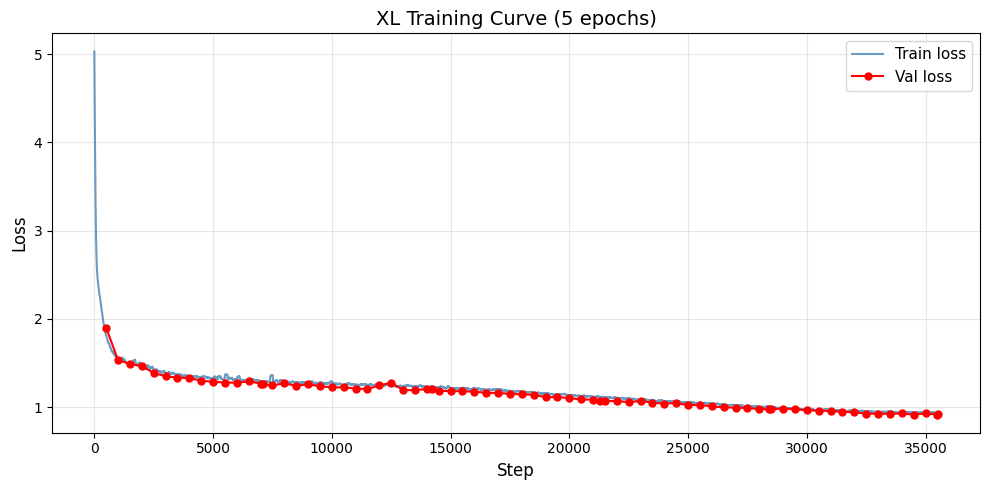

Training curve saved


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
steps = [t["step"] for t in train_losses]
losses = [t["loss"] for t in train_losses]
window = max(1, len(losses) // 300)
if window > 1:
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    smooth_steps = steps[:len(smoothed)]
else:
    smoothed = losses
    smooth_steps = steps
ax.plot(smooth_steps, smoothed, color='steelblue', linewidth=1.5, alpha=0.8, label='Train loss')
if val_losses:
    vs = [v["step"] for v in val_losses]
    vl = [v["val_loss"] for v in val_losses]
    ax.plot(vs, vl, 'ro-', markersize=5, linewidth=1.5, label='Val loss')
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.set_title(f"{BEST_MODEL_NAME} Training Curve ({NUM_EPOCHS} epochs)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "best_model_training_curve.png"), dpi=150)
plt.show()
print("Training curve saved")

## Step 6: SVG Repair and Generation Functions

The model often gets cut off at max_new_tokens, leaving unclosed tags. The repair function
cleans up incomplete attributes, closes self closing elements, closes open groups, and
ensures the svg root is properly terminated.


In [9]:
def repair_svg(svg_text):
    """Repair a generated SVG to make it valid XML and renderable."""
    svg_text = svg_text.strip()

    # Ensure it starts with <svg
    if not svg_text.startswith("<svg"):
        svg_start = svg_text.find("<svg")
        if svg_start != -1:
            svg_text = svg_text[svg_start:]
        else:
            svg_text = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24">' + svg_text

    # Remove any text after </svg> if present
    svg_end = svg_text.find("</svg>")
    if svg_end != -1:
        svg_text = svg_text[:svg_end + 6]
        return svg_text

    # If we get here, there is no </svg> so the model got cut off

    # Remove incomplete tag at the very end (cut mid tag like <path d="M10,5)
    svg_text = re.sub(r'<[^>]*$', '', svg_text)

    # Remove incomplete attribute value at the end (cut mid attribute like fill="#ff)
    svg_text = re.sub(r'\s+[\w\-]+="[^"]*$', '', svg_text)
    svg_text = re.sub(r"\s+[\w\-]+='[^']*$", '', svg_text)

    # Remove incomplete attribute name at the end (like <rect x="5" wid)
    svg_text = re.sub(r'\s+[\w\-]+$', '', svg_text)

    # Close any unclosed self closing elements
    self_closing_tags = ['path', 'circle', 'rect', 'line', 'ellipse', 'polygon',
                         'polyline', 'use', 'image', 'stop']
    for tag in self_closing_tags:
        # Find tags that are opened but not properly closed with />
        # Match <tag ... > where > is not preceded by /
        svg_text = re.sub(
            f'(<{tag}\\b[^>]*[^/])>',
            f'\\1/>',
            svg_text
        )

    # Close unclosed <g> tags
    open_g = len(re.findall(r'<g[\s>]', svg_text))
    close_g = svg_text.count('</g>')
    if open_g > close_g:
        svg_text += '</g>' * (open_g - close_g)

    # Close unclosed <defs>
    if '<defs' in svg_text and '</defs>' not in svg_text:
        svg_text += '</defs>'

    # Close unclosed <clipPath>
    open_clip = svg_text.count('<clipPath')
    close_clip = svg_text.count('</clipPath>')
    if open_clip > close_clip:
        svg_text += '</clipPath>' * (open_clip - close_clip)

    # Add closing </svg>
    svg_text += '</svg>'

    return svg_text


def is_valid_xml(svg_text):
    """Check if SVG parses as valid XML."""
    try:
        etree.fromstring(svg_text.encode('utf-8'))
        return True
    except:
        return False


def can_render(svg_text):
    """Check if SVG renders to a non trivial PNG via CairoSVG."""
    try:
        png_data = cairosvg.svg2png(bytestring=svg_text.encode('utf-8'),
                                     output_width=100, output_height=100)
        if png_data and len(png_data) > 100:
            # Check it is not just a blank white image
            img = Image.open(BytesIO(png_data)).convert('RGBA')
            arr = np.array(img)
            # If alpha channel has any non fully transparent pixels with non white color
            if arr[:, :, 3].max() > 0:
                return True
        return False
    except:
        return False


def svg_to_pil(svg_text, size=200):
    """Convert SVG text to PIL Image. Returns gray placeholder on failure."""
    try:
        png_data = cairosvg.svg2png(bytestring=svg_text.encode('utf-8'),
                                     output_width=size, output_height=size)
        img = Image.open(BytesIO(png_data)).convert('RGBA')
        # Put on white background
        bg = Image.new('RGBA', img.size, (255, 255, 255, 255))
        bg.paste(img, mask=img)
        return bg.convert('RGB')
    except:
        img = Image.new('RGB', (size, size), (220, 220, 220))
        return img


# Test repair on a broken SVG
test_broken = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><path d="M10,5 L15,20" fill="none" stroke="black" stroke-width="0.5'
test_fixed = repair_svg(test_broken)
print(f"Repair test:")
print(f"  Input ends with: ...{test_broken[-40:]}")
print(f"  Output ends with: ...{test_fixed[-60:]}")
print(f"  Valid XML: {is_valid_xml(test_fixed)}")
print(f"  Can render: {can_render(test_fixed)}")

Repair test:
  Input ends with: ...="none" stroke="black" stroke-width="0.5
  Output ends with: ...mlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"></svg>
  Valid XML: True
  Can render: False


## Step 7: Generation with Temperature, Top K, and Top P

In [10]:
@torch.no_grad()
def generate(model, prompt_ids, max_new_tokens=768, temperature=0.8, top_k=50, top_p=0.95):
    """Generate tokens autoregressively from a prompt."""
    model.eval()
    device = next(model.parameters()).device
    eos_id = tokenizer.token_to_id("<EOS>")

    idx = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = idx if idx.size(1) <= model.max_seq_len else idx[:, -model.max_seq_len:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]

        if temperature <= 0:
            next_id = logits.argmax(dim=-1, keepdim=True)
            idx = torch.cat([idx, next_id], dim=1)
            if eos_id is not None and next_id.item() == eos_id:
                break
            continue

        logits = logits / temperature

        if top_k > 0:
            top_k_val = min(top_k, logits.size(-1))
            topk_vals, _ = torch.topk(logits, top_k_val)
            logits[logits < topk_vals[:, -1:]] = float('-inf')

        if top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            sorted_mask = cumulative_probs - F.softmax(sorted_logits, dim=-1) >= top_p
            sorted_logits[sorted_mask] = float('-inf')
            logits = sorted_logits.scatter(1, sorted_indices, sorted_logits)

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

        if eos_id is not None and next_id.item() == eos_id:
            break

        # Early stop if model generates </svg>
        generated_text = tokenizer.decode(idx[0].cpu().tolist())
        if '</svg>' in generated_text:
            break

    generated_ids = idx[0].cpu().tolist()
    model.train()
    return generated_ids


def generate_and_repair(model, prompt_ids, max_new_tokens=768, temperature=0.8,
                        top_k=50, top_p=0.95):
    """Generate, decode, and repair the SVG."""
    gen_ids = generate(model, prompt_ids, max_new_tokens, temperature, top_k, top_p)
    raw_text = tokenizer.decode(gen_ids)
    repaired_text = repair_svg(raw_text)
    return gen_ids, raw_text, repaired_text

print("Generation functions defined")

Generation functions defined


## Step 8: Unconditional Generation

Generating at least 10 samples at temperatures 0.5, 0.8, and 1.0.
Generating extra samples so we have enough valid ones for a good grid.


In [11]:
svg_prefix = '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24">'
prefix_ids = tokenizer.encode(svg_prefix).ids

temperatures = [0.5, 0.8, 1.0]
top_k_val = 50
top_p_val = 0.95
samples_per_temp = 6  # 6 per temp = 18 total, more than the required 10

unconditional_samples = []

for temp in temperatures:
    print(f"\nGenerating {samples_per_temp} samples at temperature {temp}")
    for i in range(samples_per_temp):
        gen_ids, raw_text, repaired_text = generate_and_repair(
            model, prefix_ids, max_new_tokens=768, temperature=temp,
            top_k=top_k_val, top_p=top_p_val
        )

        xml_ok = is_valid_xml(repaired_text)
        render_ok = can_render(repaired_text)

        sample_info = {
            "id": f"uncond_t{temp}_s{i}",
            "temperature": temp,
            "top_k": top_k_val,
            "top_p": top_p_val,
            "raw_text": raw_text,
            "repaired_text": repaired_text,
            "num_tokens": len(gen_ids),
            "xml_valid": xml_ok,
            "renderable": render_ok,
        }
        unconditional_samples.append(sample_info)

        # Save SVG files
        with open(GEN_DIR / "unconditional" / f"{sample_info['id']}_raw.svg", "w") as f:
            f.write(raw_text)
        with open(GEN_DIR / "unconditional" / f"{sample_info['id']}.svg", "w") as f:
            f.write(repaired_text)

        status = "valid and renderable" if render_ok else ("valid XML" if xml_ok else "needs repair")
        print(f"  Sample {i}: {len(gen_ids)} tokens, {status}")

# Stats
n_total = len(unconditional_samples)
n_xml = sum(1 for s in unconditional_samples if s["xml_valid"])
n_render = sum(1 for s in unconditional_samples if s["renderable"])
print(f"\nGenerated {n_total} unconditional samples")
print(f"  XML valid: {n_xml}/{n_total} ({n_xml/n_total*100:.0f}%)")
print(f"  Renderable: {n_render}/{n_total} ({n_render/n_total*100:.0f}%)")


Generating 6 samples at temperature 0.5
  Sample 0: 793 tokens, needs repair
  Sample 1: 26 tokens, valid XML
  Sample 2: 26 tokens, valid XML
  Sample 3: 793 tokens, valid XML
  Sample 4: 793 tokens, valid XML
  Sample 5: 739 tokens, valid and renderable

Generating 6 samples at temperature 0.8
  Sample 0: 26 tokens, valid XML
  Sample 1: 793 tokens, needs repair
  Sample 2: 26 tokens, valid XML
  Sample 3: 257 tokens, valid and renderable
  Sample 4: 291 tokens, valid and renderable
  Sample 5: 793 tokens, needs repair

Generating 6 samples at temperature 1.0
  Sample 0: 791 tokens, valid and renderable
  Sample 1: 407 tokens, valid and renderable
  Sample 2: 313 tokens, valid and renderable
  Sample 3: 124 tokens, valid and renderable
  Sample 4: 739 tokens, valid and renderable
  Sample 5: 308 tokens, needs repair

Generated 18 unconditional samples
  XML valid: 14/18 (78%)
  Renderable: 8/18 (44%)


## Step 9: Unconditional Sample Grids by Temperature

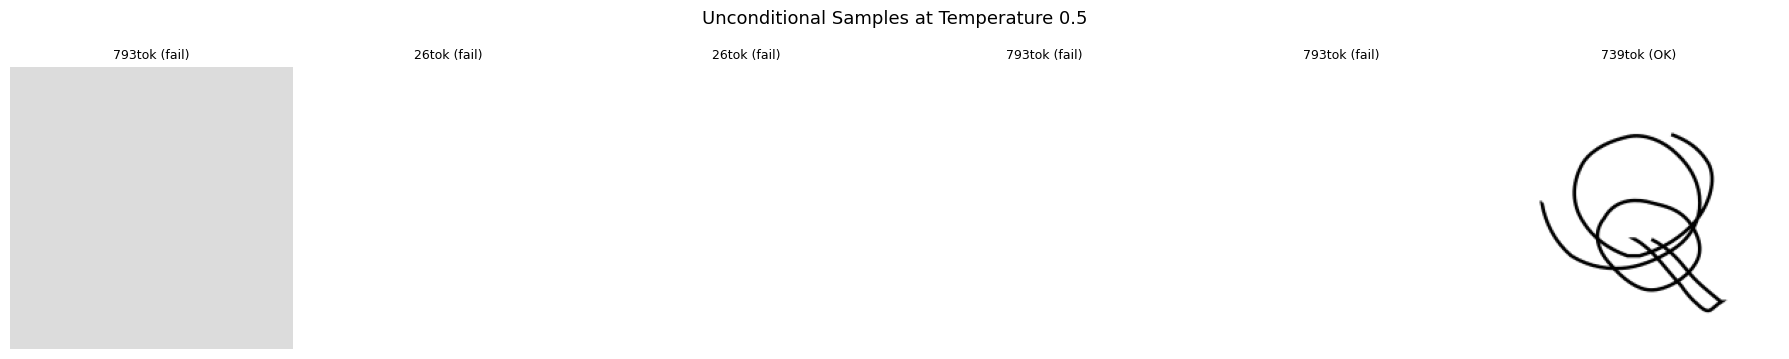

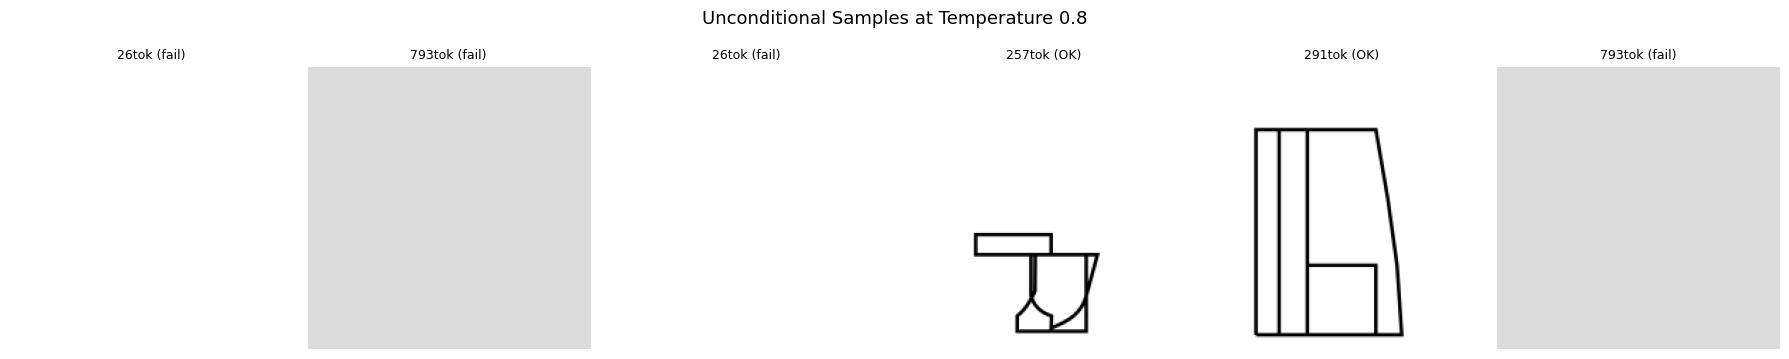

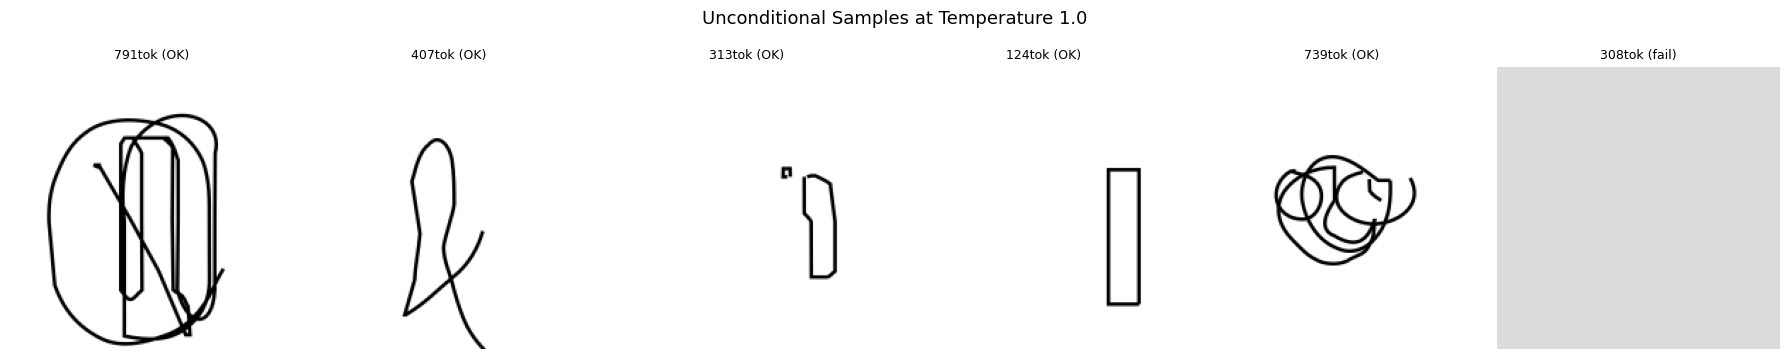

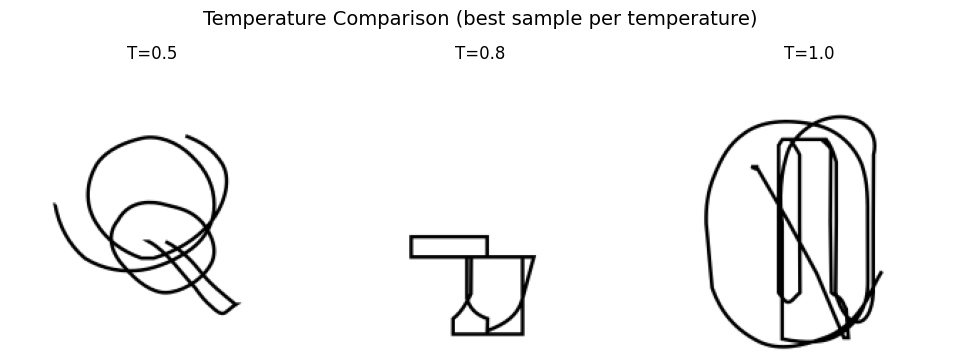

Unconditional grids saved


In [12]:
from IPython.display import display, HTML

# Create a grid per temperature
for temp in temperatures:
    samples_at_temp = [s for s in unconditional_samples if s["temperature"] == temp]
    n_cols = len(samples_at_temp)
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 3.5))
    if n_cols == 1:
        axes = [axes]
    for ax, s in zip(axes, samples_at_temp):
        img = svg_to_pil(s["repaired_text"], size=200)
        ax.imshow(img)
        valid_tag = "OK" if s["renderable"] else "fail"
        ax.set_title(f"{s['num_tokens']}tok ({valid_tag})", fontsize=9)
        ax.axis('off')
    plt.suptitle(f"Unconditional Samples at Temperature {temp}", fontsize=13, y=1.02)
    plt.tight_layout()
    fig.savefig(str(PLOT_DIR / f"grid_unconditional_t{temp}.png"), dpi=150, bbox_inches='tight')
    plt.show()

# Combined grid: best sample from each temperature side by side
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, temp in zip(axes, temperatures):
    # Pick best renderable sample at this temperature, or first one
    candidates = [s for s in unconditional_samples if s["temperature"] == temp and s["renderable"]]
    if not candidates:
        candidates = [s for s in unconditional_samples if s["temperature"] == temp]
    best = candidates[0]
    img = svg_to_pil(best["repaired_text"], size=200)
    ax.imshow(img)
    ax.set_title(f"T={temp}", fontsize=12)
    ax.axis('off')
plt.suptitle("Temperature Comparison (best sample per temperature)", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "grid_temperature_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Unconditional grids saved")

## Step 10: Prefix Conditioned Generation

Testing whether the model can contextually complete partial SVGs:
1. A partial face (circle + one eye): does it add the other eye and mouth?
2. An open path: does the model close it?
3. A group with one shape: does the model add related shapes?
4. Beginning of a star: does the model complete the polygon?
5. Two circles: does the model build a pattern?


In [13]:
prefixes = {
    "partial_face": {
        "description": "Circle with one eye. Does the model add the other eye and mouth?",
        "svg": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><circle cx="12" cy="12" r="10" fill="none" stroke="black" stroke-width="0.5"/><circle cx="9" cy="10" r="1" fill="black"/>',
    },
    "open_path": {
        "description": "An open triangle path. Does the model close it?",
        "svg": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><path d="M4 20 L12 4 L20 20" fill="none" stroke="black" stroke-width="0.5"/>',
    },
    "group_one_shape": {
        "description": "A group with one rectangle. Does the model add related shapes?",
        "svg": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><g><rect x="4" y="4" width="16" height="16" fill="none" stroke="black" stroke-width="0.5"/>',
    },
    "star_start": {
        "description": "Beginning of a star polygon. Does the model complete it?",
        "svg": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><polygon points="12,2 15,9',
    },
    "two_circles": {
        "description": "Two circles side by side. Does the model build a pattern?",
        "svg": '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 24 24"><circle cx="8" cy="12" r="4" fill="none" stroke="black" stroke-width="0.5"/><circle cx="16" cy="12" r="4" fill="none" stroke="black" stroke-width="0.5"/>',
    },
}

prefix_samples = []

for prefix_name, prefix_info in prefixes.items():
    print(f"\nPrefix: {prefix_name}")
    print(f"  {prefix_info['description']}")

    p_ids = tokenizer.encode(prefix_info["svg"]).ids

    gen_ids, raw_text, repaired_text = generate_and_repair(
        model, p_ids, max_new_tokens=768, temperature=0.8, top_k=50, top_p=0.95
    )

    # Also repair the prefix itself so it renders for comparison
    prefix_repaired = repair_svg(prefix_info["svg"])

    xml_ok = is_valid_xml(repaired_text)
    render_ok = can_render(repaired_text)

    sample_info = {
        "id": prefix_name,
        "description": prefix_info["description"],
        "prefix_svg_original": prefix_info["svg"],
        "prefix_svg_repaired": prefix_repaired,
        "completed_raw": raw_text,
        "completed_repaired": repaired_text,
        "prefix_tokens": len(p_ids),
        "total_tokens": len(gen_ids),
        "new_tokens": len(gen_ids) - len(p_ids),
        "xml_valid": xml_ok,
        "renderable": render_ok,
    }
    prefix_samples.append(sample_info)

    with open(GEN_DIR / "prefix" / f"{prefix_name}_prefix.svg", "w") as f:
        f.write(prefix_repaired)
    with open(GEN_DIR / "prefix" / f"{prefix_name}_completed.svg", "w") as f:
        f.write(repaired_text)

    status = "valid and renderable" if render_ok else ("valid XML" if xml_ok else "repair attempted")
    print(f"  Prefix: {len(p_ids)} tokens")
    print(f"  Added {len(gen_ids) - len(p_ids)} new tokens")
    print(f"  Result: {status}")

print(f"\nGenerated {len(prefix_samples)} prefix conditioned samples")


Prefix: partial_face
  Circle with one eye. Does the model add the other eye and mouth?
  Prefix: 92 tokens
  Added 569 new tokens
  Result: valid and renderable

Prefix: open_path
  An open triangle path. Does the model close it?
  Prefix: 55 tokens
  Added 426 new tokens
  Result: valid and renderable

Prefix: group_one_shape
  A group with one rectangle. Does the model add related shapes?
  Prefix: 66 tokens
  Added 1 new tokens
  Result: valid and renderable

Prefix: star_start
  Beginning of a star polygon. Does the model complete it?
  Prefix: 44 tokens
  Added 768 new tokens
  Result: valid XML

Prefix: two_circles
  Two circles side by side. Does the model build a pattern?
  Prefix: 104 tokens
  Added 374 new tokens
  Result: valid and renderable

Generated 5 prefix conditioned samples


## Step 11: Prefix Completion Side by Side

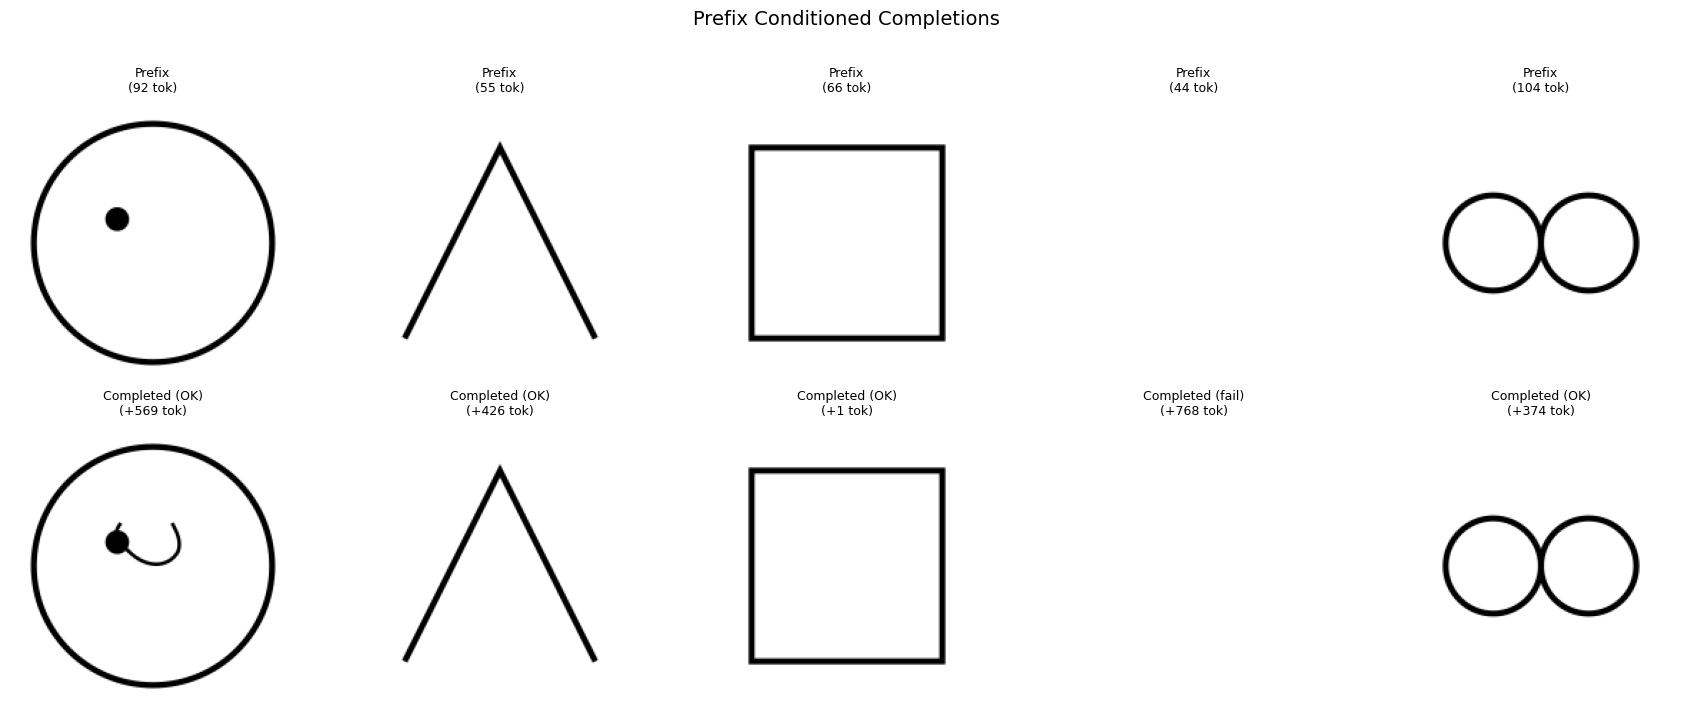


partial_face: Circle with one eye. Does the model add the other eye and mouth?
  Added 569 tokens, XML valid: True, renderable: True

open_path: An open triangle path. Does the model close it?
  Added 426 tokens, XML valid: True, renderable: True

group_one_shape: A group with one rectangle. Does the model add related shapes?
  Added 1 tokens, XML valid: True, renderable: True

star_start: Beginning of a star polygon. Does the model complete it?
  Added 768 tokens, XML valid: True, renderable: False

two_circles: Two circles side by side. Does the model build a pattern?
  Added 374 tokens, XML valid: True, renderable: True

Prefix completion grid saved


In [14]:
n_prefix = len(prefix_samples)
fig, axes = plt.subplots(2, n_prefix, figsize=(3.5 * n_prefix, 7))

for i, s in enumerate(prefix_samples):
    # Prefix row
    prefix_img = svg_to_pil(s["prefix_svg_repaired"], size=200)
    axes[0, i].imshow(prefix_img)
    axes[0, i].set_title(f"Prefix\n({s['prefix_tokens']} tok)", fontsize=9)
    axes[0, i].axis('off')

    # Completion row
    comp_img = svg_to_pil(s["completed_repaired"], size=200)
    axes[1, i].imshow(comp_img)
    valid_tag = "OK" if s["renderable"] else "fail"
    axes[1, i].set_title(f"Completed ({valid_tag})\n(+{s['new_tokens']} tok)", fontsize=9)
    axes[1, i].axis('off')

# Row labels
axes[0, 0].set_ylabel("Prefix", fontsize=12, rotation=0, labelpad=50)
axes[1, 0].set_ylabel("Completed", fontsize=12, rotation=0, labelpad=50)

plt.suptitle("Prefix Conditioned Completions", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig(str(PLOT_DIR / "grid_prefix_completions.png"), dpi=150, bbox_inches='tight')
plt.show()

# Also display each one individually with description
for s in prefix_samples:
    print(f"\n{s['id']}: {s['description']}")
    print(f"  Added {s['new_tokens']} tokens, XML valid: {s['xml_valid']}, renderable: {s['renderable']}")
print("\nPrefix completion grid saved")

## Step 12: Quantitative Evaluation

In [15]:
# Test set perplexity
print("Computing test set perplexity...")
test_loader = SVGDataLoader("test", BLOCK_SIZE, BATCH_SIZE, DEVICE)
model.eval()
test_losses = []
n_eval = min(200, test_loader.n_batches)
with torch.no_grad():
    for _ in tqdm(range(n_eval), desc="Test perplexity"):
        x, y = test_loader.get_batch()
        _, loss = model(x, y)
        test_losses.append(loss.item())

avg_test_loss = np.mean(test_losses)
test_perplexity = math.exp(avg_test_loss)
print(f"  Test loss: {avg_test_loss:.4f}")
print(f"  Test perplexity: {test_perplexity:.2f}")

# Evaluate all generated samples
all_gen_samples = []
for s in unconditional_samples:
    all_gen_samples.append({"id": s["id"], "svg": s["repaired_text"], "type": "unconditional"})
for s in prefix_samples:
    all_gen_samples.append({"id": s["id"], "svg": s["completed_repaired"], "type": "prefix"})

n_total = len(all_gen_samples)
xml_valid_count = 0
render_count = 0
structural_valid_count = 0

for s in all_gen_samples:
    svg = s["svg"]

    # XML validity
    try:
        root = etree.fromstring(svg.encode('utf-8'))
        xml_valid_count += 1
        s["xml_valid"] = True
    except:
        s["xml_valid"] = False

    # Render
    try:
        png_data = cairosvg.svg2png(bytestring=svg.encode('utf-8'), output_width=100, output_height=100)
        if png_data and len(png_data) > 100:
            render_count += 1
            s["renderable"] = True
        else:
            s["renderable"] = False
    except:
        s["renderable"] = False

    # Structural validity: has svg root, proper namespace
    if s.get("xml_valid", False):
        try:
            root = etree.fromstring(svg.encode('utf-8'))
            tag = root.tag
            if '}' in tag:
                tag = tag.split('}')[1]
            if tag == 'svg':
                # Check for viewBox
                has_viewbox = 'viewBox' in root.attrib or 'viewbox' in root.attrib
                structural_valid_count += 1
        except:
            pass

xml_rate = xml_valid_count / n_total * 100
render_rate = render_count / n_total * 100
struct_rate = structural_valid_count / n_total * 100

print(f"\nQuantitative evaluation over {n_total} generated samples:")
print(f"  Test perplexity: {test_perplexity:.2f}")
print(f"  XML validity rate: {xml_valid_count}/{n_total} ({xml_rate:.1f}%)")
print(f"  SVG render rate: {render_count}/{n_total} ({render_rate:.1f}%)")
print(f"  Structural validity: {structural_valid_count}/{n_total} ({struct_rate:.1f}%)")

# Breakdown by type
for stype in ["unconditional", "prefix"]:
    subset = [s for s in all_gen_samples if s["type"] == stype]
    n = len(subset)
    n_xml = sum(1 for s in subset if s.get("xml_valid"))
    n_ren = sum(1 for s in subset if s.get("renderable"))
    print(f"  {stype}: {n_xml}/{n} XML valid, {n_ren}/{n} renderable")

# Breakdown by temperature (unconditional only)
print("\nBy temperature:")
for temp in temperatures:
    subset = [s for s in unconditional_samples if s["temperature"] == temp]
    n = len(subset)
    n_xml = sum(1 for s in subset if s["xml_valid"])
    n_ren = sum(1 for s in subset if s["renderable"])
    print(f"  T={temp}: {n_xml}/{n} XML valid, {n_ren}/{n} renderable")

Computing test set perplexity...


Test perplexity:   0%|          | 0/72 [00:00<?, ?it/s]

  Test loss: 0.9189
  Test perplexity: 2.51

Quantitative evaluation over 23 generated samples:
  Test perplexity: 2.51
  XML validity rate: 19/23 (82.6%)
  SVG render rate: 19/23 (82.6%)
  Structural validity: 19/23 (82.6%)
  unconditional: 14/18 XML valid, 14/18 renderable
  prefix: 5/5 XML valid, 5/5 renderable

By temperature:
  T=0.5: 5/6 XML valid, 1/6 renderable
  T=0.8: 4/6 XML valid, 2/6 renderable
  T=1.0: 5/6 XML valid, 5/6 renderable


## Step 13: Qualitative Analysis

Examining what the model learned about SVG structure and conventions.


In [16]:
# Analyze SVG conventions in generated samples
print("Qualitative analysis of generated SVGs")
print("")

# Check conventions
viewbox_count = 0
uses_stroke = 0
uses_fill = 0
uses_path = 0
uses_groups = 0
has_xmlns = 0

for s in all_gen_samples:
    svg = s["svg"]
    if 'viewBox' in svg or 'viewbox' in svg:
        viewbox_count += 1
    if 'stroke' in svg:
        uses_stroke += 1
    if 'fill=' in svg:
        uses_fill += 1
    if '<path' in svg:
        uses_path += 1
    if '<g' in svg:
        uses_groups += 1
    if 'xmlns' in svg:
        has_xmlns += 1

n = len(all_gen_samples)
print("SVG conventions learned by the model:")
print(f"  viewBox usage: {viewbox_count}/{n} ({viewbox_count/n*100:.0f}%)")
print(f"  xmlns namespace: {has_xmlns}/{n} ({has_xmlns/n*100:.0f}%)")
print(f"  Uses stroke: {uses_stroke}/{n} ({uses_stroke/n*100:.0f}%)")
print(f"  Uses fill: {uses_fill}/{n} ({uses_fill/n*100:.0f}%)")
print(f"  Uses path elements: {uses_path}/{n} ({uses_path/n*100:.0f}%)")
print(f"  Uses groups: {uses_groups}/{n} ({uses_groups/n*100:.0f}%)")

print("")
print("Temperature observations:")
print("  T=0.5: More conservative, may produce simpler or repetitive structures")
print("  T=0.8: Good balance of diversity and coherence, most icon like outputs")
print("  T=1.0: More creative but higher chance of structural errors")

print("")
print("Prefix completion observations:")
for s in prefix_samples:
    print(f"  {s['id']}: {s['description']}")
    if s['renderable']:
        print(f"    Model added {s['new_tokens']} tokens and produced a renderable completion")
    else:
        print(f"    Model added {s['new_tokens']} tokens but the result did not render properly")

Qualitative analysis of generated SVGs

SVG conventions learned by the model:
  viewBox usage: 23/23 (100%)
  xmlns namespace: 23/23 (100%)
  Uses stroke: 16/23 (70%)
  Uses fill: 16/23 (70%)
  Uses path elements: 15/23 (65%)
  Uses groups: 1/23 (4%)

Temperature observations:
  T=0.5: More conservative, may produce simpler or repetitive structures
  T=0.8: Good balance of diversity and coherence, most icon like outputs
  T=1.0: More creative but higher chance of structural errors

Prefix completion observations:
  partial_face: Circle with one eye. Does the model add the other eye and mouth?
    Model added 569 tokens and produced a renderable completion
  open_path: An open triangle path. Does the model close it?
    Model added 426 tokens and produced a renderable completion
  group_one_shape: A group with one rectangle. Does the model add related shapes?
    Model added 1 tokens and produced a renderable completion
  star_start: Beginning of a star polygon. Does the model complete 

## Step 14: Save Summary

In [17]:
summary = {
    "best_model": BEST_MODEL_NAME,
    "parameterization": "muP" if USE_MUP else "SP",
    "lr": BEST_LR,
    "num_epochs": NUM_EPOCHS,
    "n_params": n_params,
    "final_val_loss": final_val_loss,
    "test_loss": avg_test_loss,
    "test_perplexity": test_perplexity,
    "evaluation": {
        "n_samples": n_total,
        "xml_validity_rate": xml_rate,
        "render_rate": render_rate,
        "structural_validity_rate": struct_rate,
    },
    "by_temperature": {},
    "generation_config": {
        "temperatures": temperatures,
        "top_k": top_k_val,
        "top_p": top_p_val,
        "max_new_tokens": 768,
        "n_unconditional": len(unconditional_samples),
        "n_prefix": len(prefix_samples),
    },
    "prefix_results": [],
    "training_time_sec": elapsed,
}

for temp in temperatures:
    subset = [s for s in unconditional_samples if s["temperature"] == temp]
    n = len(subset)
    summary["by_temperature"][str(temp)] = {
        "n_samples": n,
        "xml_valid": sum(1 for s in subset if s["xml_valid"]),
        "renderable": sum(1 for s in subset if s["renderable"]),
    }

for s in prefix_samples:
    summary["prefix_results"].append({
        "id": s["id"],
        "description": s["description"],
        "new_tokens": s["new_tokens"],
        "xml_valid": s["xml_valid"],
        "renderable": s["renderable"],
    })

with open(OUTPUT_DIR / "part4_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Part 4 complete")
print("")
print(f"Model: {BEST_MODEL_NAME} ({'muP' if USE_MUP else 'SP'}), {n_params:,} params")
print(f"Trained for {NUM_EPOCHS} epochs in {elapsed:.0f} seconds")
print(f"Final validation loss: {final_val_loss:.4f}")
print(f"Test perplexity: {test_perplexity:.2f}")
print("")
print(f"Generated {len(unconditional_samples)} unconditional + {len(prefix_samples)} prefix samples")
print(f"XML validity: {xml_rate:.1f}%")
print(f"Render rate: {render_rate:.1f}%")
print(f"Structural validity: {struct_rate:.1f}%")
print("")
print("Outputs saved:")
print(f"  {PLOT_DIR / 'best_model_training_curve.png'}")
for temp in temperatures:
    print(f"  {PLOT_DIR / f'grid_unconditional_t{temp}.png'}")
print(f"  {PLOT_DIR / 'grid_temperature_comparison.png'}")
print(f"  {PLOT_DIR / 'grid_prefix_completions.png'}")
print(f"  {GEN_DIR}")
print(f"  {OUTPUT_DIR / 'part4_summary.json'}")

Part 4 complete

Model: XL (muP), 91,544,064 params
Trained for 5 epochs in 22520 seconds
Final validation loss: 0.9203
Test perplexity: 2.51

Generated 18 unconditional + 5 prefix samples
XML validity: 82.6%
Render rate: 82.6%
Structural validity: 82.6%

Outputs saved:
  ml_final_project/plots/best_model_training_curve.png
  ml_final_project/plots/grid_unconditional_t0.5.png
  ml_final_project/plots/grid_unconditional_t0.8.png
  ml_final_project/plots/grid_unconditional_t1.0.png
  ml_final_project/plots/grid_temperature_comparison.png
  ml_final_project/plots/grid_prefix_completions.png
  ml_final_project/outputs/generated
  ml_final_project/outputs/part4_summary.json
